In [1]:
import sys,os
baile_path=os.path.abspath(os.path.join("..","src"))
if not baile_path in sys.path:
    sys.path.append(baile_path)
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
import SimpleSearch as sp

Los ejemplos anteriores deben asignarse como parte de un nodo. Un *nodo de SimpleSearch* tiene los siguientes atributos:

* **state**: el estado del sistema en este nodo.
* **parent**: nodo que lo generó (por defecto `"None"`).
* **depth**: profundidad del árbol del nodo, es decir, el número de movimientos desde la raíz (por defecto `0`).
* **step_cost**: costo del movimiento individual desde el padre hacia este nodo (por defecto `1`).
* **cost**: costo acumulado desde la raíz, $g(n)$. Es calculado por la búsqueda como $g(n) = g(parent) + step\_cost$, por lo que **no** necesitas definirlo manualmente.
* **delta**: valor heurístico del nodo $h(n)$ (por defecto `0`). Se completa en $A^*$ usando la función *heuristic*.
* **op**: cadena de texto (`String`) que contiene la descripción de la operación generadora (por defecto `""`).

El nodo también proporciona $f(n) = g(n) + h(n)$ a través del método **f()**, el cual es el valor utilizado para ordenar la cola de prioridad de $A^*$.

In [3]:
#Definir el estado
start=sp.node((2,2,2,2,2), depth=0, parent=None)
start1=sp.node((0,0,0,0,0,0), depth=0, parent=None)

In [4]:
def plot_tablero(state):
    n=len(state)
    tablero=[[(i+j)%2 for j in range(n)] for i in range(n)]
    fig, ax=plt.subplots(figsize=(5,5))
    ax.imshow(tablero, cmap="gray")
    for r,c in enumerate(state):
        ax.text(r,c,"♕", ha="center", va="center", fontsize=30, color="red")
    plt.show()

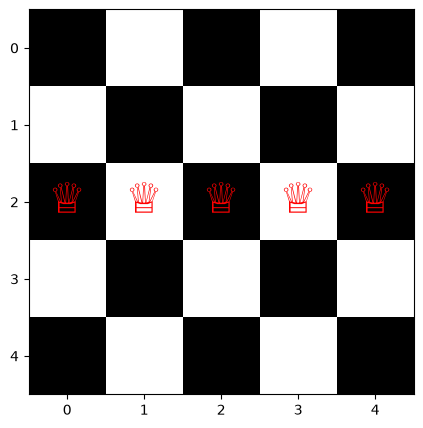

In [5]:
plot_tablero(start.state)

In [6]:
# Definir una funcion sucesor
def sucesorNR(nodo):
    S=[]
    st, n=nodo.state, len(nodo.state)
    for i in range(n):
        adelante=list(st)
        atras=list(st)
        if st[i]+1<n:
            adelante[i]=st[i]+1
            S.append(sp.node(tuple(adelante), depth=nodo.depth+1, parent=nodo))
        if st[i]-1>=0:
            atras[i]=st[i]-1
            S.append(sp.node(tuple(atras), depth=nodo.depth+1, parent=nodo))
    return S
    
    

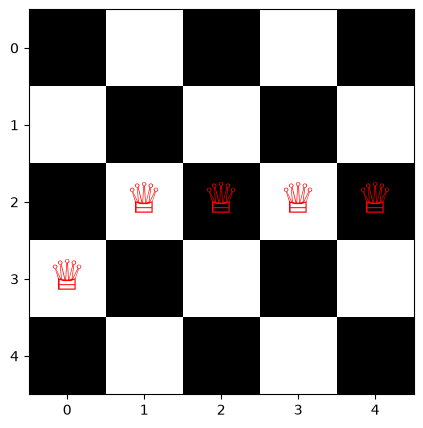

In [7]:
S=sucesorNR(start)
plot_tablero(S[0].state)


In [8]:
# Definir una meta
def contar_ataques(*nodos):
    nodo=nodos[0]
    tb=nodo.state
    n=len(tb)
    ataques=0
    for i in range(n-1):
        for j in range(i+1, n):
            if tb[i]==tb[j]:
                ataques+=1
            if abs(i-j)==abs(tb[i]-tb[j]):
                ataques+=1
    return ataques

def meta(*nodos):
    st=nodos[0]
    return contar_ataques(st)==0

In [9]:
meta(start)

False

In [10]:
meta(S[0])

False

In [11]:
bfs=sp.TreeSearch(start, sucesorNR, meta, strategy="bfs")
dfs=sp.TreeSearch(start, sucesorNR, meta, strategy="dfs")
bas=sp.TreeSearch(start, sucesorNR, meta, strategy="a*", heuristic=contar_ataques)

In [12]:
bfs.iterations

0

In [13]:
%%time
r1=bfs.find()

CPU times: user 5.24 ms, sys: 24 μs, total: 5.26 ms
Wall time: 5.27 ms


In [14]:
%%time
r2=dfs.find()

CPU times: user 706 μs, sys: 18 μs, total: 724 μs
Wall time: 720 μs


In [15]:
%%time 
r3=bas.find()

CPU times: user 233 μs, sys: 45 μs, total: 278 μs
Wall time: 319 μs


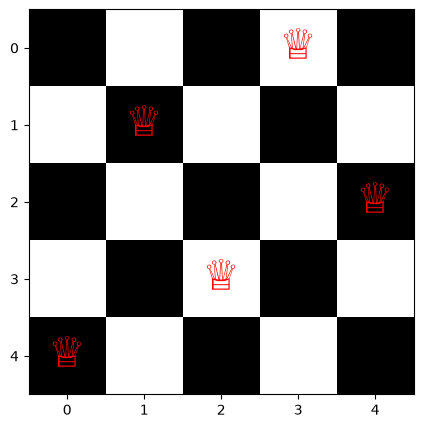

In [16]:
plot_tablero(r1.state)

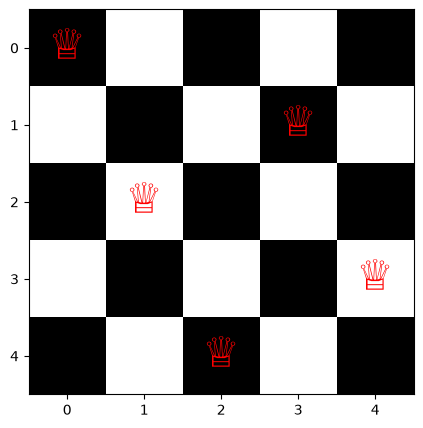

In [17]:
plot_tablero(r2.state)

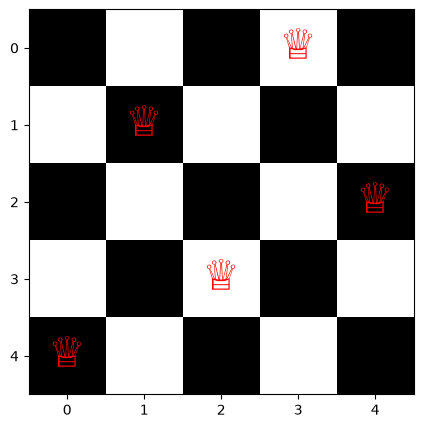

In [18]:
plot_tablero(r3.state)

In [19]:
bfs.iterations

1248

In [20]:
dfs.iterations

146

In [28]:
resultados=pd.DataFrame({"Busqueda":["BFS", "DFS", "A*(AC)"], "Iteraciones":[bfs.iterations, dfs.iterations, bas.iterations] })

In [29]:
resultados

,Busqueda,Iteraciones
0,BFS,1248
1,DFS,146
2,A*(AC),11


In [23]:
r1.getPath()

[((2, 2, 2, 2, 2), '', 0),
 ((3, 2, 2, 2, 2), '', 1),
 ((4, 2, 2, 2, 2), '', 2),
 ((4, 1, 2, 2, 2), '', 3),
 ((4, 1, 3, 2, 2), '', 4),
 ((4, 1, 3, 1, 2), '', 5),
 ((4, 1, 3, 0, 2), '', 6)]

In [24]:
print(r3)

state: (4, 1, 3, 0, 2), op: , depth: 6, g: 6, h: 0


In [25]:
print(r1)

state: (4, 1, 3, 0, 2), op: , depth: 6, g: 6, h: 0


In [26]:
print(r3)

state: (4, 1, 3, 0, 2), op: , depth: 6, g: 6, h: 0


In [27]:
print(r2)

state: (0, 2, 4, 1, 3), op: , depth: 146, g: 146, h: 0
